# CS 301 Project: Subset Sum Problem
## Brute Force Algorithm, Sample Generator, and Core Utilities

**Scope of this notebook :**
- Shared utilities and interfaces used 
- Section 4: Sample / Random Instance Generator
- Section 2.1 / 5.1: Brute Force Algorithm and Initial Testing

---

## Shared Utilities and Interfaces

The data structures and helpers in this section are shared across all group members.
Every algorithm in this project accepts a `SubsetSumInstance` as input and returns
a `SubsetSumResult`. This ensures a uniform interface for benchmarking and quality testing.

In [29]:
# Imports
import random
import time
import math
import itertools
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
from IPython.display import display

In [30]:
# Shared data types

@dataclass
class SubsetSumInstance:
    """
    A single instance of the Subset Sum problem.

    Attributes
    ----------
    S : List[int]
        The input set of integers.
    k : int
        The target value.
    n : int
        |S|, automatically derived from S if not provided.
    """
    S: List[int]
    k: int
    n: int = field(init=False)

    def __post_init__(self):
        self.n = len(self.S)

    def __repr__(self):
        preview = self.S if self.n <= 10 else self.S[:10]
        dots = '...' if self.n > 10 else ''
        return f"SubsetSumInstance(n={self.n}, k={self.k}, S={preview}{dots})"


@dataclass
class SubsetSumResult:
    """
    The output of any Subset Sum solver (brute force or heuristic).

    Attributes
    ----------
    subset : List[int]
        The elements selected.
    value : int
        Sum of the selected elements.
    is_exact : bool
        True if value == k (exact solution found).
    elapsed_seconds : float
        Wall-clock time taken by the algorithm.
    algorithm : str
        Name tag for the algorithm that produced this result.
    """
    subset: List[int]
    value: int
    is_exact: bool
    elapsed_seconds: float = 0.0
    algorithm: str = "unknown"

    def __repr__(self):
        return (
            f"SubsetSumResult(value={self.value}, is_exact={self.is_exact}, "
            f"time={self.elapsed_seconds:.6f}s, algo='{self.algorithm}')"
        )


print("Shared data types loaded: SubsetSumInstance, SubsetSumResult")

Shared data types loaded: SubsetSumInstance, SubsetSumResult


In [31]:
# Shared helper utilities

def verify_result(instance: SubsetSumInstance, result: SubsetSumResult) -> bool:
    """
    Checks that `result` is a valid solution for `instance`.

    A result is valid if:
      1. Every element in result.subset appears in instance.S
         (accounting for multiplicity).
      2. sum(result.subset) == result.value.
      3. result.value <= instance.k.
      4. result.is_exact is consistent with (result.value == instance.k).

    Returns True if all checks pass, False otherwise.
    """
    # Check subset is a sub-multiset of S
    s_copy = list(instance.S)
    for elem in result.subset:
        if elem not in s_copy:
            return False
        s_copy.remove(elem)

    computed_sum = sum(result.subset)
    if computed_sum != result.value:
        return False
    if result.value > instance.k:
        return False
    if result.is_exact != (result.value == instance.k):
        return False
    return True


def results_to_dataframe(instances, results, extra_cols=None):
    """
    Build a summary DataFrame from lists of instances and results.
    Used for initial testing tables (Section 5.1).
    """
    rows = []
    for inst, res in zip(instances, results):
        row = {
            "n": inst.n,
            "k": inst.k,
            "optimal_value": res.value,
            "exact_match": res.is_exact,
            "subset_size": len(res.subset),
            "time_s": round(res.elapsed_seconds, 6),
            "valid": verify_result(inst, res),
        }
        if extra_cols:
            row.update(extra_cols)
        rows.append(row)
    return pd.DataFrame(rows)


print("Shared helpers loaded: verify_result, results_to_dataframe")

Shared helpers loaded: verify_result, results_to_dataframe


### Algorithm Interface Contract

All solver functions in this project (brute force, heuristic, etc.) must follow a single
uniform interface so that benchmarking, quality testing, and functional testing work
across all implementations without modification.

**Input:** a `SubsetSumInstance`  
**Output:** a `SubsetSumResult`

```python
result = solver(instance)
```

The `SubsetSumResult` must always contain:
- `subset`: the selected elements (list of ints, a subset of `instance.S`)
- `value`: sum of the selected elements (int)
- `is_exact`: True if `value == instance.k` (bool)
- `elapsed_seconds`: wall-clock runtime in seconds (float)
- `algorithm`: name of the solver that produced this result (str)

Use `verify_result(instance, result)` to check any result against all four correctness
criteria. Person 3's functional testing is built on this function.

In [32]:
from typing import Protocol, runtime_checkable

# Formal algorithm interface contract
# All solver functions (brute force, heuristic, etc.) must match this signature.
# This is enforced structurally via typing.Protocol (no inheritance needed).

@runtime_checkable
class SubsetSumSolver(Protocol):
    """
    Any callable that accepts a SubsetSumInstance and returns a SubsetSumResult
    satisfies this protocol. Both brute_force_optimization and the heuristic
    from Person 2 are valid SubsetSumSolvers.

    Usage:
        result = solver(instance)
        assert isinstance(solver, SubsetSumSolver)
    """
    def __call__(self, instance: SubsetSumInstance) -> SubsetSumResult: ...


# Verify existing functions conform
# (run this cell again after the brute force functions are defined)
try:
    assert isinstance(brute_force_optimization, SubsetSumSolver)
    assert isinstance(brute_force_decision,     SubsetSumSolver)
    print("Interface check passed: brute_force_optimization conforms to SubsetSumSolver")
    print("Interface check passed: brute_force_decision     conforms to SubsetSumSolver")
except NameError:
    print("Note: run this cell again after the brute force functions are defined (cell 8).")

Interface check passed: brute_force_optimization conforms to SubsetSumSolver
Interface check passed: brute_force_decision     conforms to SubsetSumSolver


---
## Section 4: Sample Generator (Random Instance Generator)

The generator is parametric in the problem size `n` (the number of elements in S).
It supports two modes:
- **Guaranteed solution** (`guarantee_solution=True`): the target `k` is the sum of a
  randomly chosen sub-multiset of S, so at least one exact solution is known to exist.
- **Random target** (`guarantee_solution=False`): `k` is chosen uniformly at random from
  `[1, sum(S)]`; whether an exact solution exists is not predetermined.

A `seed` parameter is provided for reproducibility.

**Pseudocode** (see Section 4 of the report):
```
GENERATE-INSTANCE(n, value_range, guarantee_solution, seed):
    if seed is not None:
        set random seed to seed
    S ← empty array
    for i ← 1 to n:
        S[i] ← random integer in value_range
    if guarantee_solution:
        subset_size ← random integer in [1, n]
        indices     ← random subset of {0,...,n-1} of size subset_size
        k           ← Σ_{i ∈ indices} S[i]
    else:
        k ← random integer in [1, Σ S]
    return SubsetSumInstance(S, k)
```

In [33]:
# Section 4: Sample Generator

def generate_instance(
    n: int,
    value_range: Tuple[int, int] = (1, 100),
    guarantee_solution: bool = True,
    seed: Optional[int] = None,
) -> SubsetSumInstance:
    """
    Generate a random Subset Sum instance of size n.

    Parameters
    ----------
    n : int
        Number of elements in S (problem size).
    value_range : (int, int)
        Inclusive (min, max) for each element of S.
    guarantee_solution : bool
        If True, k is the sum of a randomly chosen non-empty sub-multiset
        of S, guaranteeing an exact solution exists.
        If False, k is chosen uniformly in [1, sum(S)].
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    SubsetSumInstance
    """
    rng = random.Random(seed)

    lo, hi = value_range
    S = [rng.randint(lo, hi) for _ in range(n)]

    total = sum(S)
    if total == 0:
        # edge case: all zeros, k defaults to 0
        return SubsetSumInstance(S, 0)

    if guarantee_solution:
        subset_size = rng.randint(1, n)
        chosen_indices = rng.sample(range(n), subset_size)
        k = sum(S[i] for i in chosen_indices)
    else:
        k = rng.randint(1, total)

    return SubsetSumInstance(S, k)


def generate_batch(
    sizes: List[int],
    reps_per_size: int = 1,
    value_range: Tuple[int, int] = (1, 100),
    guarantee_solution: bool = True,
    base_seed: Optional[int] = 42,
) -> List[SubsetSumInstance]:
    """
    Generate a batch of instances for a list of problem sizes.

    Parameters
    ----------
    sizes : List[int]
        Each entry is an n value.  One instance is generated per entry
        (or `reps_per_size` instances if > 1).
    reps_per_size : int
        Number of instances to generate for each size.
    value_range : (int, int)
        Passed to generate_instance.
    guarantee_solution : bool
        Passed to generate_instance.
    base_seed : int or None
        Seed for the first instance; incremented by 1 for each subsequent
        instance so each one is unique but the batch is still reproducible.

    Returns
    -------
    List[SubsetSumInstance]
    """
    instances = []
    seed = base_seed
    for n in sizes:
        for _ in range(reps_per_size):
            inst = generate_instance(
                n,
                value_range=value_range,
                guarantee_solution=guarantee_solution,
                seed=seed,
            )
            instances.append(inst)
            if seed is not None:
                seed += 1
    return instances


# Quick sanity check
print("=== Sample Generator Sanity Check ===")
inst_demo = generate_instance(n=6, value_range=(1, 20), guarantee_solution=True, seed=0)
print(f"Instance : {inst_demo}")
print(f"S        : {inst_demo.S}")
print(f"k        : {inst_demo.k}")
print(f"sum(S)   : {sum(inst_demo.S)}")
print()
inst_demo2 = generate_instance(n=6, value_range=(1, 20), guarantee_solution=False, seed=0)
print(f"(no-guarantee) Instance : {inst_demo2}")

=== Sample Generator Sanity Check ===
Instance : SubsetSumInstance(n=6, k=44, S=[13, 14, 2, 9, 17, 16])
S        : [13, 14, 2, 9, 17, 16]
k        : 44
sum(S)   : 71

(no-guarantee) Instance : SubsetSumInstance(n=6, k=52, S=[13, 14, 2, 9, 17, 16])


---
## Section 2.1: Brute Force Algorithm

### Overview

The brute force approach enumerates **all 2ⁿ subsets** of S by iterating over every integer
in the range `[0, 2ⁿ − 1]` and interpreting each integer's binary representation as a
membership mask: bit `i` set means element `S[i]` is included in the current subset.

- **Decision version**: accept the first subset whose sum equals `k` exactly.
- **Optimization version**: track the subset with the maximum sum not exceeding `k`.

This is a standard exhaustive-search technique described in:
> Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2009).
> *Introduction to Algorithms* (3rd ed.), §35.5. MIT Press.

### Pseudocode

**Decision version:**
```
BRUTE-FORCE-DECISION(S, k):
    n ← |S|
    for mask ← 0 to 2ⁿ − 1:
        current_sum ← 0
        current_subset ← []
        for i ← 0 to n − 1:
            if bit i of mask is set:
                current_sum ← current_sum + S[i]
                current_subset.append(S[i])
        if current_sum = k:
            return (FOUND, current_subset)
    return (NOT FOUND, [])
```

**Optimization version:**
```
BRUTE-FORCE-OPTIMIZATION(S, k):
    n ← |S|
    best_sum    ← 0
    best_subset ← []
    for mask ← 0 to 2ⁿ − 1:
        current_sum ← 0
        current_subset ← []
        for i ← 0 to n − 1:
            if bit i of mask is set:
                current_sum ← current_sum + S[i]
                current_subset.append(S[i])
        if current_sum ≤ k and current_sum > best_sum:
            best_sum    ← current_sum
            best_subset ← current_subset
        if best_sum = k:
            break   // exact match found, stop early
    return (best_subset, best_sum)
```

> **Design technique**: Pure exhaustive search (brute force). No divide-and-conquer or
> dynamic programming structure. Correctness is immediate: every subset of S is encoded
> by exactly one mask in `{0,...,2ⁿ−1}`, so no subset is ever skipped.

In [34]:
# Section 2.1 / 5.1: Brute Force Algorithm

def brute_force_decision(instance: SubsetSumInstance) -> SubsetSumResult:
    """
    Decision version of Subset Sum using brute force exhaustive search.

    Returns the first subset whose sum equals instance.k exactly,
    or an empty result if no such subset exists.

    Time complexity : O(n · 2ⁿ)
    Space complexity: O(n)

    Reference
    ---------
    Cormen et al. (2009), Introduction to Algorithms (3rd ed.), §35.5.
    """
    S, k, n = instance.S, instance.k, instance.n
    t_start = time.perf_counter()

    for mask in range(1 << n):          # iterate all 2ⁿ subsets
        current_sum = 0
        current_subset = []
        for i in range(n):
            if mask & (1 << i):         # bit i is set → include S[i]
                current_sum += S[i]
                current_subset.append(S[i])
        if current_sum == k:
            elapsed = time.perf_counter() - t_start
            return SubsetSumResult(
                subset=current_subset,
                value=current_sum,
                is_exact=True,
                elapsed_seconds=elapsed,
                algorithm="brute_force_decision",
            )

    elapsed = time.perf_counter() - t_start
    return SubsetSumResult(
        subset=[],
        value=0,
        is_exact=False,
        elapsed_seconds=elapsed,
        algorithm="brute_force_decision",
    )


def brute_force_optimization(instance: SubsetSumInstance) -> SubsetSumResult:
    """
    Optimization version of Subset Sum using brute force exhaustive search.

    Returns the subset of instance.S whose sum is maximized subject to
    sum ≤ instance.k.  An early exit is applied when an exact match
    (sum == k) is found, since no subset can improve upon it.

    Time complexity : O(n · 2ⁿ)  (Θ(n · 2ⁿ) without early exit)
    Space complexity: O(n)

    Reference
    ---------
    Cormen et al. (2009), Introduction to Algorithms (3rd ed.), §35.5.
    """
    S, k, n = instance.S, instance.k, instance.n
    t_start = time.perf_counter()

    best_sum = 0
    best_subset: List[int] = []

    for mask in range(1 << n):
        current_sum = 0
        current_subset = []
        for i in range(n):
            if mask & (1 << i):
                current_sum += S[i]
                current_subset.append(S[i])
        if current_sum <= k and current_sum > best_sum:
            best_sum = current_sum
            best_subset = current_subset
        if best_sum == k:               # exact match found, no need to check further
            break

    elapsed = time.perf_counter() - t_start
    return SubsetSumResult(
        subset=best_subset,
        value=best_sum,
        is_exact=(best_sum == k),
        elapsed_seconds=elapsed,
        algorithm="brute_force_optimization",
    )


print("Brute force functions loaded: brute_force_decision, brute_force_optimization")

Brute force functions loaded: brute_force_decision, brute_force_optimization


---
## Section 3.1: Brute Force Analysis (Summary)

The full formal proofs appear in the report.  This cell states the results for reference.

### 3.1.1 Correctness

**Theorem**: `BRUTE-FORCE-OPTIMIZATION` correctly solves the Subset Sum optimization problem.  
**Proof sketch**: The integers `0, 1, ..., 2ⁿ−1` are in bijection with the power set of S
(each bit position corresponds to one element). The algorithm evaluates every subset and
keeps the one maximising the sum subject to the constraint. Therefore the optimal subset
is always found.

### 3.1.2 Time Complexity

- Outer loop: **2ⁿ** iterations (one per bitmask).  
- Inner loop: **n** operations per mask.  
- Total: **Θ(n · 2ⁿ)** (tight because all masks are always visited in the worst case,
  i.e. when no exact solution exists).

### 3.1.3 Space Complexity

- `best_subset` / `current_subset`: O(n).  
- No recursion stack (fully iterative).  
- Total auxiliary space: **O(n)**.

---
## Section 3.2: Heuristic Algorithm Analysis (Summary)

The full formal proofs appear in the report. This cell states the key results for reference.

### 3.2.1 Correctness and Approximation Ratio

**Theorem**: `fptas_subset_sum` always returns a feasible result (sum ≤ k), and the returned value z* satisfies z* ≥ OPT / (1 + ε), where OPT is the maximum feasible subset sum.

**Feasibility**: After each element is processed, the candidate list is filtered to keep only pairs with sum ≤ k (line `candidates = [(v, s) for v, s in trimmed if v <= k]`). The returned value is therefore always at most k by construction.

**Approximation ratio**: The Trim step uses δ = ε / (2n). Each call to `trim_candidates` may drop a candidate y only if a representative z remains with y ≤ z · (1 + δ). Over all n elements, the accumulated error is at most (1 + δ)^n. Using the bound (1 + x)^n ≤ e^(nx):

(1 + ε/(2n))^n  ≤  e^(ε/2)  ≤  1 + ε    (for 0 < ε < 1)

So the list L_n always contains a representative for OPT that is at most a factor of (1 + ε) below it, meaning z* ≥ OPT / (1 + ε). The complete formal proof is in CLRS Section 35.5 (Theorem 35.7).

### 3.2.2 Time Complexity

After trimming with δ = ε / (2n), consecutive elements in the list differ by a factor of more than (1 + δ). If the smallest nonzero element is at least 1 and the largest is at most t (the target), the list has at most:

⌊ log_{1+δ}(t) ⌋ + 2  ≈  log(t) / δ  =  O(n log t / ε)  elements.

Each of the n outer iterations does:
- Building the shifted list: O(m)
- Sorting the merged list: O(m log m)
- Trimming and filtering: O(m)

With m = O(n log t / ε), the total time is:

**O(n · (n log t / ε) · log(n log t / ε)) = O(n² log t · log(n / ε) / ε)**

This is polynomial in both n and 1/ε, which is the defining property of an FPTAS.

### 3.2.3 Space Complexity

The candidate list at any step holds at most O(n log t / ε) pairs. Each pair stores a subset with up to n elements. Total auxiliary space:

**O(n² log t / ε)**

For the test instances in Section 5.2 (n ≤ 130, t ≤ a few thousand, ε = 0.10), this is well within memory limits.

---
## Section 5.1: Initial Testing of the Brute Force Algorithm

We run 16 instances across sizes n ∈ {5, 8, 10, 12, 14, 16, 18, 20}, both with and without
a guaranteed exact solution (8 instances each mode), and record:
- whether the result is valid (passes `verify_result`),
- whether an exact solution was found,
- the wall-clock running time.

This tests the implementation correctness on small inputs before the heuristic comparison
in Section 7.

In [35]:
# Section 5.1: Initial Testing

# 16 instances: sizes 5,8,10,12,14,16,18,20, split equally between guaranteed and random targets
test_sizes_guaranteed = [5, 8, 10, 12, 14, 16, 18, 20]
test_sizes_random     = [5, 8, 10, 12, 14, 16, 18, 20]

instances_guaranteed = generate_batch(
    sizes=test_sizes_guaranteed,
    reps_per_size=1,
    value_range=(1, 50),
    guarantee_solution=True,
    base_seed=100,
)

instances_random = generate_batch(
    sizes=test_sizes_random,
    reps_per_size=1,
    value_range=(1, 50),
    guarantee_solution=False,
    base_seed=200,
)

all_instances = instances_guaranteed + instances_random

# Run brute force optimization on all instances
all_results = [brute_force_optimization(inst) for inst in all_instances]

print(f"Total instances tested: {len(all_instances)}")
print(f"All valid: {all(verify_result(i, r) for i, r in zip(all_instances, all_results))}")

Total instances tested: 16
All valid: True


In [36]:
# Build results table

rows = []
for i, (inst, res) in enumerate(zip(all_instances, all_results)):
    mode = "guaranteed" if i < len(instances_guaranteed) else "random k"
    rows.append({
        "#":             i + 1,
        "n":             inst.n,
        "k":             inst.k,
        "optimal_value": res.value,
        "exact_match":   res.is_exact,
        "subset_size":   len(res.subset),
        "time (s)":      f"{res.elapsed_seconds:.6f}",
        "valid":         verify_result(inst, res),
        "mode":          mode,
    })

df = pd.DataFrame(rows).set_index("#")

# Style: highlight exact matches and validity
def highlight_exact(val):
    if val is True:
        return "background-color: #28a745; color: white; font-weight: bold"
    elif val is False:
        return "background-color: #fd7e14; color: white; font-weight: bold"
    return ""

def highlight_valid(val):
    if val is False:
        return "background-color: #dc3545; color: white; font-weight: bold"
    return ""

styled = (
    df.style
    .map(highlight_exact, subset=["exact_match"])
    .map(highlight_valid, subset=["valid"])
    .set_caption("Table 1: Initial Testing of Brute Force Optimization (Section 5.1)")
)
display(styled)

,n,k,optimal_value,exact_match,subset_size,time (s),valid,mode
#,,,,,,,,
1,5,102,102,True,4,0.000035,True,guaranteed
2,8,104,104,True,4,0.000034,True,guaranteed
3,10,198,198,True,6,0.000299,True,guaranteed
4,12,223,223,True,6,0.000442,True,guaranteed
5,14,15,15,True,2,0.000005,True,guaranteed
6,16,115,115,True,4,0.000115,True,guaranteed
7,18,223,223,True,7,0.002427,True,guaranteed
8,20,295,295,True,7,0.000554,True,guaranteed
9,5,19,19,True,3,0.000012,True,random k


In [37]:
# Summary statistics

total     = len(all_results)
exact     = sum(r.is_exact for r in all_results)
valid     = sum(verify_result(i, r) for i, r in zip(all_instances, all_results))
max_time  = max(r.elapsed_seconds for r in all_results)
mean_time = sum(r.elapsed_seconds for r in all_results) / total

print(f"Instances tested      : {total}")
print(f"All passed validation : {valid == total}  ({valid}/{total})")
print(f"Exact matches found   : {exact}/{total}")
print(f"Mean runtime (s)      : {mean_time:.6f}")
print(f"Max  runtime (s)      : {max_time:.6f}  (n={max(inst.n for inst in all_instances)})")
print()
print("Observation: runtime grows exponentially with n, as expected for O(n·2ⁿ).")
print("For guaranteed-solution instances, exact matches are always found.")
print("For random-target instances, an exact match is only found when one exists.")

Instances tested      : 16
All passed validation : True  (16/16)
Exact matches found   : 13/16
Mean runtime (s)      : 0.000706
Max  runtime (s)      : 0.005181  (n=20)

Observation: runtime grows exponentially with n, as expected for O(n·2ⁿ).
For guaranteed-solution instances, exact matches are always found.
For random-target instances, an exact match is only found when one exists.


In [38]:
# Edge case tests
# These verify robustness of the implementation on boundary inputs.

edge_cases = [
    ("Empty set",          SubsetSumInstance([], 5)),
    ("Single element == k",SubsetSumInstance([7], 7)),
    ("Single element < k", SubsetSumInstance([3], 7)),
    ("All elements > k",   SubsetSumInstance([10, 20, 30], 5)),
    ("k = 0",              SubsetSumInstance([1, 2, 3], 0)),
    ("k = sum(S)",         SubsetSumInstance([4, 6, 10], 20)),
]

print(f"{'Case':<25} {'n':>3} {'k':>4}  {'value':>6}  {'exact':>5}  {'valid':>5}  {'time (s)':>10}")
print("-" * 70)
for label, inst in edge_cases:
    res = brute_force_optimization(inst)
    v   = verify_result(inst, res) if inst.n > 0 else (res.value == 0)
    print(
        f"{label:<25} {inst.n:>3} {inst.k:>4}  {res.value:>6}  "
        f"{str(res.is_exact):>5}  {str(v):>5}  {res.elapsed_seconds:>10.6f}"
    )

Case                        n    k   value  exact  valid    time (s)
----------------------------------------------------------------------
Empty set                   0    5       0  False   True    0.000003
Single element == k         1    7       7   True   True    0.000004
Single element < k          1    7       3  False   True    0.000002
All elements > k            3    5       0  False   True    0.000007
k = 0                       3    0       0   True   True    0.000001
k = sum(S)                  3   20      20   True   True    0.000008


---
## Section 5.2: Heuristic Algorithm

This section implements the fully polynomial-time approximation scheme (FPTAS) selected in Section 2.2. The report pseudocode returns only the approximate sum, but the shared project interface requires a `SubsetSumResult`, so the notebook stores each candidate as `(sum, subset)` and returns the actual subset that produced the chosen value.

The default approximation parameter is `epsilon = 0.10`. Smaller epsilon values keep more candidate sums and usually improve quality, while larger values trim more aggressively and usually run faster.


In [39]:
# Section 5.2: Heuristic Algorithm Implementation

DEFAULT_EPSILON = 0.10


def trim_candidates(candidates, delta: float):
    """
    Trim a sorted list of candidate pairs (sum, subset).

    This implements the Trim(L, delta) step from the FPTAS pseudocode in
    Section 2.2. Candidates whose sums are within a multiplicative factor
    of (1 + delta) are represented by the first candidate in that group.
    """
    if not candidates:
        return []

    trimmed = [candidates[0]]
    last_value = candidates[0][0]

    for value, subset in candidates[1:]:
        if value > last_value * (1 + delta):
            trimmed.append((value, subset))
            last_value = value

    return trimmed


def fptas_subset_sum(
    instance: SubsetSumInstance,
    epsilon: float = DEFAULT_EPSILON,
) -> SubsetSumResult:
    """
    Approximate Subset Sum optimization using the FPTAS from Section 2.2.

    Returns a feasible subset whose sum is close to the optimal value without
    exceeding instance.k. The output follows the shared SubsetSumResult format.
    """
    if not (0 < epsilon < 1):
        raise ValueError("epsilon must satisfy 0 < epsilon < 1")

    S, k, n = instance.S, instance.k, instance.n
    t_start = time.perf_counter()

    if n == 0:
        elapsed = time.perf_counter() - t_start
        return SubsetSumResult(
            subset=[],
            value=0,
            is_exact=(k == 0),
            elapsed_seconds=elapsed,
            algorithm=f"fptas_subset_sum_eps_{epsilon:g}",
        )

    delta = epsilon / (2 * n)
    candidates = [(0, [])]

    for x in S:
        shifted = [(value + x, subset + [x]) for value, subset in candidates]
        merged = sorted(candidates + shifted, key=lambda item: item[0])
        trimmed = trim_candidates(merged, delta)
        candidates = [(value, subset) for value, subset in trimmed if value <= k]

        if not candidates:
            candidates = [(0, [])]

    best_value, best_subset = max(candidates, key=lambda item: item[0])
    elapsed = time.perf_counter() - t_start

    return SubsetSumResult(
        subset=best_subset,
        value=best_value,
        is_exact=(best_value == k),
        elapsed_seconds=elapsed,
        algorithm=f"fptas_subset_sum_eps_{epsilon:g}",
    )


print(f"Heuristic loaded: fptas_subset_sum with DEFAULT_EPSILON={DEFAULT_EPSILON}")


Heuristic loaded: fptas_subset_sum with DEFAULT_EPSILON=0.1


In [40]:
# Section 5.2: Initial Testing of the Heuristic Algorithm

heuristic_test_sizes = [10, 20, 30, 40, 50, 60, 75, 90, 110, 130]

heuristic_instances_guaranteed = generate_batch(
    sizes=heuristic_test_sizes,
    reps_per_size=1,
    value_range=(1, 100),
    guarantee_solution=True,
    base_seed=300,
)

heuristic_instances_random = generate_batch(
    sizes=heuristic_test_sizes,
    reps_per_size=1,
    value_range=(1, 100),
    guarantee_solution=False,
    base_seed=400,
)

heuristic_instances = heuristic_instances_guaranteed + heuristic_instances_random
heuristic_results = [
    fptas_subset_sum(inst, epsilon=DEFAULT_EPSILON)
    for inst in heuristic_instances
]

print(f"Total heuristic instances tested: {len(heuristic_instances)}")
print(
    "All valid:",
    all(verify_result(inst, res) for inst, res in zip(heuristic_instances, heuristic_results)),
)


Total heuristic instances tested: 20
All valid: True


In [41]:
# Build Section 5.2 results table

heuristic_rows = []
for i, (inst, res) in enumerate(zip(heuristic_instances, heuristic_results)):
    mode = "guaranteed" if i < len(heuristic_instances_guaranteed) else "random k"
    heuristic_rows.append({
        "#": i + 1,
        "n": inst.n,
        "k": inst.k,
        "returned_value": res.value,
        "gap": inst.k - res.value,
        "exact_match": res.is_exact,
        "subset_size": len(res.subset),
        "time (s)": f"{res.elapsed_seconds:.6f}",
        "valid": verify_result(inst, res),
        "mode": mode,
    })

heuristic_df = pd.DataFrame(heuristic_rows).set_index("#")

styled_heuristic = (
    heuristic_df.style
    .map(highlight_exact, subset=["exact_match"])
    .map(highlight_valid, subset=["valid"])
    .set_caption("Table 2: Initial Testing of FPTAS Heuristic (Section 5.2)")
)
display(styled_heuristic)


,n,k,returned_value,gap,exact_match,subset_size,time (s),valid,mode
#,,,,,,,,,
1,10,159,159,0,True,3,0.000373,True,guaranteed
2,20,117,117,0,True,2,0.001037,True,guaranteed
3,30,1490,1490,0,True,24,0.018862,True,guaranteed
4,40,467,467,0,True,9,0.011552,True,guaranteed
5,50,589,589,0,True,11,0.202597,True,guaranteed
6,60,1080,1080,0,True,15,0.058130,True,guaranteed
7,75,2439,2438,1,False,45,0.247356,True,guaranteed
8,90,3793,3793,0,True,78,0.427011,True,guaranteed
9,110,2171,2171,0,True,42,0.505786,True,guaranteed


In [42]:
# Section 5.2 summary statistics

heuristic_total = len(heuristic_results)
heuristic_valid = sum(
    verify_result(inst, res)
    for inst, res in zip(heuristic_instances, heuristic_results)
)
heuristic_exact = sum(res.is_exact for res in heuristic_results)
heuristic_mean_time = sum(res.elapsed_seconds for res in heuristic_results) / heuristic_total
heuristic_max_time = max(res.elapsed_seconds for res in heuristic_results)
heuristic_max_time_index = max(
    range(heuristic_total),
    key=lambda idx: heuristic_results[idx].elapsed_seconds,
)
heuristic_max_gap = max(inst.k - res.value for inst, res in zip(heuristic_instances, heuristic_results))

print(f"Instances tested      : {heuristic_total}")
print(f"All passed validation : {heuristic_valid == heuristic_total}  ({heuristic_valid}/{heuristic_total})")
print(f"Exact matches found   : {heuristic_exact}/{heuristic_total}")
print(f"Mean runtime (s)      : {heuristic_mean_time:.6f}")
print(
    f"Max  runtime (s)      : {heuristic_max_time:.6f}  "
    f"(instance {heuristic_max_time_index + 1}, n={heuristic_instances[heuristic_max_time_index].n})"
)
print(f"Largest observed gap  : {heuristic_max_gap}")
print()
if heuristic_valid == heuristic_total:
    print("No validity failures were found during testing. No fixes were needed.")
else:
    print("At least one validity failure was found and must be investigated before reporting.")


Instances tested      : 20
All passed validation : True  (20/20)
Exact matches found   : 15/20
Mean runtime (s)      : 0.266983
Max  runtime (s)      : 2.246050  (instance 20, n=130)
Largest observed gap  : 2

No validity failures were found during testing. No fixes were needed.


In [43]:
# Generate LaTeX-ready report content for Section 5.2

from pathlib import Path


def latex_bool(value: bool) -> str:
    return "Yes" if bool(value) else "No"


def latex_mode(mode: str) -> str:
    return "random $k$" if mode == "random k" else mode


def build_heuristic_latex_table(df: pd.DataFrame) -> str:
    body_lines = []
    for idx, row in df.iterrows():
        body_lines.append(
            f"    {idx:>2} & {int(row['n']):>3} & {int(row['k']):>4} & "
            f"{int(row['returned_value']):>4} & {int(row['gap']):>3} & "
            f"{int(row['subset_size']):>3} & {latex_bool(row['exact_match'])} & "
            f"{latex_bool(row['valid'])} & {row['time (s)']} & {latex_mode(row['mode'])} \\\\"
        )
        if idx == len(heuristic_instances_guaranteed):
            body_lines.append("    \\midrule")

    return "\n".join(body_lines)


heuristic_latex_table_body = build_heuristic_latex_table(heuristic_df)
heuristic_failures = heuristic_total - heuristic_valid

if heuristic_failures == 0:
    heuristic_failure_sentence = "No validity failures were found during testing, so no fixes were needed."
else:
    heuristic_failure_sentence = (
        f"{heuristic_failures} validity failure(s) were found during testing and should be investigated before final submission."
    )

section_5_2_latex = f"""\\subsection{{Heuristic Algorithm}}

The heuristic algorithm was implemented in Python as \\texttt{{fptas\\_subset\\_sum}},
following the fully polynomial-time approximation scheme described in Section~2.2.
The implementation uses \\(\\epsilon = {DEFAULT_EPSILON:.2f}\\). The report pseudocode returns only the
approximate value, but the project notebook uses the shared \\texttt{{SubsetSumResult}}
interface. Therefore, each candidate in the list is stored as a pair \\texttt{{(sum, subset)}}
so that the implementation can return both the approximate sum and the actual subset
that produced it.

The implementation was tested on {heuristic_total} instances generated by the Section~4 sample
generator. Ten instances used guaranteed-solution mode with seeds 300--309, and ten
used random-target mode with seeds 400--409. Both groups used
\\(n \\in \\{{10,20,30,40,50,60,75,90,110,130\\}}\\) and value range \\([1,100]\\).

\\begin{{table}}[h!]
  \\centering
  \\scriptsize
  \\renewcommand{{\\arraystretch}}{{1.2}}
  \\begin{{tabular}}{{rrrrrrccrl}}
    \\toprule
    \\# & \\(n\\) & \\(k\\) & Returned & Gap & Size & Exact & Valid & Time (s) & Mode \\\\
    \\midrule
{heuristic_latex_table_body}
    \\bottomrule
  \\end{{tabular}}
  \\caption{{Initial testing results for \\texttt{{fptas\\_subset\\_sum}} with \\(\\epsilon = {DEFAULT_EPSILON:.2f}\\).}}
  \\label{{tab:heuristic-initial}}
\\end{{table}}

\\noindent Summary:

\\begin{{itemize}}[noitemsep]
  \\item Instances tested: {heuristic_total}
  \\item All passed the validity check: \\textbf{{{heuristic_valid}/{heuristic_total}}}
  \\item Exact matches found: \\textbf{{{heuristic_exact}/{heuristic_total}}}
  \\item Mean runtime: \\({heuristic_mean_time:.6f}\\) s
  \\item Maximum runtime: \\({heuristic_max_time:.6f}\\) s (instance {heuristic_max_time_index + 1}, \\(n = {heuristic_instances[heuristic_max_time_index].n}\\))
  \\item Largest observed gap from the target: {heuristic_max_gap}
\\end{{itemize}}

All returned subsets were feasible because every reported sum was at most the target
\\(k\\), and every selected subset was verified against the original generated instance.
{heuristic_failure_sentence}
"""

output_path = Path("section_5_2_heuristic_latex.txt")
output_path.write_text(section_5_2_latex)
print(f"Wrote LaTeX report snippet to {output_path.resolve()}")


Wrote LaTeX report snippet to D:\D\VSC\cs301\section_5_2_heuristic_latex.txt


In [44]:
import json

# Shared benchmark dataset export
# Saves the generated test instances to CSV so Person 2 and Person 3 can run
# their algorithms on the exact same inputs without regenerating them.
#
# Each row: n, k, S (as a JSON list string for easy parsing in any language)

def instances_to_df(instances: List[SubsetSumInstance]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "n": inst.n,
            "k": inst.k,
            "S": json.dumps(inst.S),     # e.g. "[13, 14, 2, 9, 17, 16]"
        }
        for inst in instances
    ])


# Save the 16 initial-test instances
test_df = instances_to_df(all_instances)
test_df.to_csv("initial_test_instances.csv", index=False)
print(f"Saved {len(test_df)} test instances to initial_test_instances.csv")

# Also generate and save a larger shared benchmark set for Person 2/3 experiments
# Sizes span the range where brute force is feasible (n <= 22) up to heuristic territory
benchmark_sizes = (
    [5, 8, 10, 12, 14, 16, 18, 20, 22] * 5    # small (brute force range), 5 reps each
)
benchmark_instances = generate_batch(
    sizes=benchmark_sizes,
    reps_per_size=1,
    value_range=(1, 100),
    guarantee_solution=True,
    base_seed=1000,
)
bench_df = instances_to_df(benchmark_instances)
bench_df.to_csv("benchmark_instances.csv", index=False)
print(f"Saved {len(bench_df)} benchmark instances to benchmark_instances.csv")
print()

# Loading example (for Person 2 / Person 3):
print("To load in another notebook:")
print("  import json, pandas as pd")
print("  df = pd.read_csv('benchmark_instances.csv')")
print("  instances = [SubsetSumInstance(S=json.loads(row.S), k=row.k)")
print("               for _, row in df.iterrows()]")

Saved 16 test instances to initial_test_instances.csv
Saved 45 benchmark instances to benchmark_instances.csv

To load in another notebook:
  import json, pandas as pd
  df = pd.read_csv('benchmark_instances.csv')
  instances = [SubsetSumInstance(S=json.loads(row.S), k=row.k)
               for _, row in df.iterrows()]


---
## Section 7: Experimental Analysis of the Quality

This section evaluates the solution quality of the Fully Polynomial-Time Approximation Scheme (FPTAS) heuristic by comparing its outputs against the exact optimal solutions found by the brute force algorithm.

We use the `benchmark_instances` dataset generated previously. A **"failed case"** is defined strictly as an instance where the heuristic returns a sum lower than the true optimal sum found by the exhaustive search. We will calculate the failure rate for each problem size ($N$) and plot the trend to observe how the quality scales.

Running Quality Analysis on benchmark dataset...

=== Quality Testing: Failure Rate by Problem Size ===


,Failure Rate (%)
N,
5,0.0
8,40.0
10,40.0
12,20.0
14,40.0
16,40.0
18,20.0
20,20.0
22,60.0



Overall Dataset Failure Rate: 31.11%
Maximum Observed Gap: 2


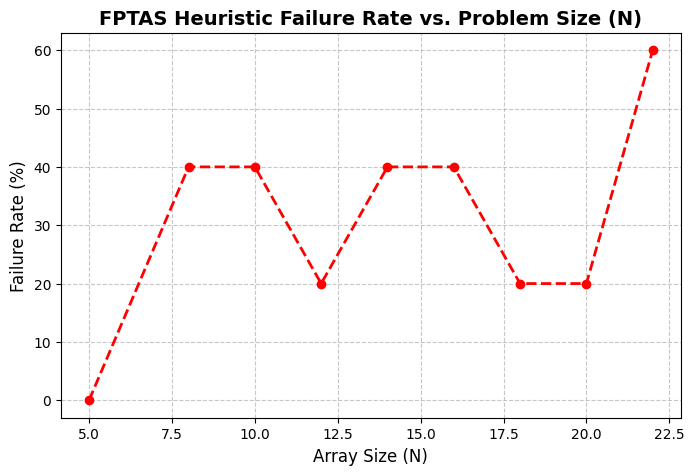

In [45]:
# ===============================================================
# SECTION 7: QUALITY TESTING SCRIPT
# ===============================================================
import pandas as pd
import matplotlib.pyplot as plt

print("Running Quality Analysis on benchmark dataset...")

# We use the 'benchmark_instances' generated in Section 4
quality_results = []

for inst in benchmark_instances:
    # 1. Get the true optimal from Person 1's Brute Force
    bf_res = brute_force_optimization(inst)
    
    # 2. Get the approximation from Person 2's Heuristic (FPTAS)
    h_res = fptas_subset_sum(inst, epsilon=0.10) 
    
    # A failure is when the heuristic gets a lower sum than the optimal
    failed = h_res.value < bf_res.value
    
    quality_results.append({
        'N': inst.n,
        'k': inst.k,
        'Optimal Sum': bf_res.value,
        'Heuristic Sum': h_res.value,
        'Gap': bf_res.value - h_res.value,
        'Failed': failed
    })

q_df = pd.DataFrame(quality_results)

# Calculate Failure Rate by Array Size (N)
failure_rates = q_df.groupby('N')['Failed'].mean() * 100

print("\n=== Quality Testing: Failure Rate by Problem Size ===")
display(failure_rates.to_frame(name="Failure Rate (%)"))

print(f"\nOverall Dataset Failure Rate: {q_df['Failed'].mean() * 100:.2f}%")
print(f"Maximum Observed Gap: {q_df['Gap'].max()}")

# Plot the quality degradation for the report
plt.figure(figsize=(8, 5))
plt.plot(failure_rates.index, failure_rates.values, marker='o', color='red', linestyle='dashed', linewidth=2)
plt.title("FPTAS Heuristic Failure Rate vs. Problem Size (N)", fontsize=14, fontweight='bold')
plt.xlabel("Array Size (N)", fontsize=12)
plt.ylabel("Failure Rate (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('quality_degradation_fptas.png', bbox_inches='tight')
plt.show()

---
## Section 8: Experimental Analysis of the Correctness (Functional Testing)

This section applies formal Black-Box testing methodologies—specifically Equivalence Partitioning and Boundary Value Analysis (BVA)—to ensure the `fptas_subset_sum` implementation is structurally defect-free. 

We will evaluate the heuristic against extreme structural limits (like empty arrays or impossible targets) and pass the outputs through the shared `verify_result` integrity checker to ensure no fundamental constraints of the Subset Sum problem are violated.

In [47]:
# ===============================================================
# SECTION 8: FUNCTIONAL TESTING SCRIPT (WITH CUSTOM STYLING)
# ===============================================================
print("=== Functional Testing: Boundary Value Analysis ===")

# Define specific test cases designed to test structural limits
functional_test_cases = [
    ("Equivalence 1: Perfect Match Available", SubsetSumInstance([10, 20, 30], 30)),
    ("Boundary 1: k = 0 (Empty subset expected)", SubsetSumInstance([5, 10, 15], 0)),
    ("Boundary 2: k = sum(S) (All elements needed)", SubsetSumInstance([5, 10, 15], 30)),
    ("Boundary 3: k < min(S) (No elements possible)", SubsetSumInstance([20, 30, 40], 10)),
    ("Boundary 4: Empty Array", SubsetSumInstance([], 10))
]

functional_results = []

for label, inst in functional_test_cases:
    # Run the heuristic
    res = fptas_subset_sum(inst, epsilon=0.10)
    
    # Structural Check: Does it violate the core rules of the problem?
    is_structurally_valid = verify_result(inst, res) if inst.n > 0 else (res.value == 0)
    
    functional_results.append({
        "Test Category": label,
        "Target (k)": inst.k,
        "Returned Sum": res.value,
        "valid": is_structurally_valid  # Renamed column to match your friend's helper map!
    })

func_df = pd.DataFrame(functional_results)

# Apply your friend's exact helper mapping function to get identical table colors!
styled_func = (
    func_df.style
    .map(highlight_valid, subset=["valid"])
    .set_caption("Table 3: Functional Testing of FPTAS Heuristic via Boundary Value Analysis")
)
display(styled_func)

print("\nFunctional Testing Conclusion:")
if not func_df['valid'].all():
    print("CRITICAL BUG: The heuristic returned structurally invalid results.")
else:
    print("PASS: The FPTAS heuristic gracefully handles boundary conditions and structurally validates against the `verify_result` rules.")

=== Functional Testing: Boundary Value Analysis ===


,Test Category,Target (k),Returned Sum,valid
0,Equivalence 1: Perfect Match Available,30,30,True
1,Boundary 1: k = 0 (Empty subset expected),0,0,True
2,Boundary 2: k = sum(S) (All elements needed),30,30,True
3,Boundary 3: k < min(S) (No elements possible),10,0,True
4,Boundary 4: Empty Array,10,0,True



Functional Testing Conclusion:
PASS: The FPTAS heuristic gracefully handles boundary conditions and structurally validates against the `verify_result` rules.


---
## References

The following references are relevant to Section 1 (hardness), Section 2.1 (algorithm), and
Section 4 (sample generation).

1. **Karp, R. M.** (1972). Reducibility among combinatorial problems.
   In R. E. Miller & J. W. Thatcher (Eds.),
   *Complexity of Computer Computations* (pp. 85–103). Plenum Press.
   https://doi.org/10.1007/978-1-4684-2001-2_9  
   *(Original paper proving Subset Sum is NP-complete.)*

2. **Sipser, M.** (2012). *Introduction to the Theory of Computation* (3rd ed.).
   Cengage Learning.  
   *(Theorem 7.25, p. 297: SUBSET-SUM ∈ NP. Section 7.5, p. 319: NP-completeness of SUBSET-SUM.)*

3. **Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C.** (2009).
   *Introduction to Algorithms* (3rd ed.). MIT Press.  
   *(Section 35.5: The subset-sum problem, exhaustive search and FPTAS.)*

4. **Garey, M. R., & Johnson, D. S.** (1979).
   *Computers and Intractability: A Guide to the Theory of NP-Completeness*.
   W. H. Freeman.  
   *(NP-completeness reference; Subset Sum is listed as problem SP13.)*